In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})
import os
import IPython

file = np.loadtxt('HW06_data.txt')

In [ ]:
theta_vals = np.linspace(0+ 1e-6,1 - 1e-6,1000)#careful about edge cases
def ppdf(prior_func, data, like_func,theta_vals, initial_vals = [2,5]):
    like_vals= like_func(theta_vals,data)
    prior_vals = prior_func(theta_vals, initial_vals)
    posterior = prior_vals * like_vals

    posterior = posterior / np.trapezoid(posterior,theta_vals) #normalize

    return posterior

def prior_func(theta_vals,initial_vals):
    a,b = initial_vals
    return theta_vals ** (a- 1) * (1-theta_vals)**(b-1)

def like_func(theta_vals,data):
    h,t = data
    return theta_vals ** (h) * (1-theta_vals) ** (t)

#first n values in the file (n<500)
def new_run(n):
    count = 1
    for i in file[:n]:
        if i == 1: 
            count+= 1
    return [count,n-count]

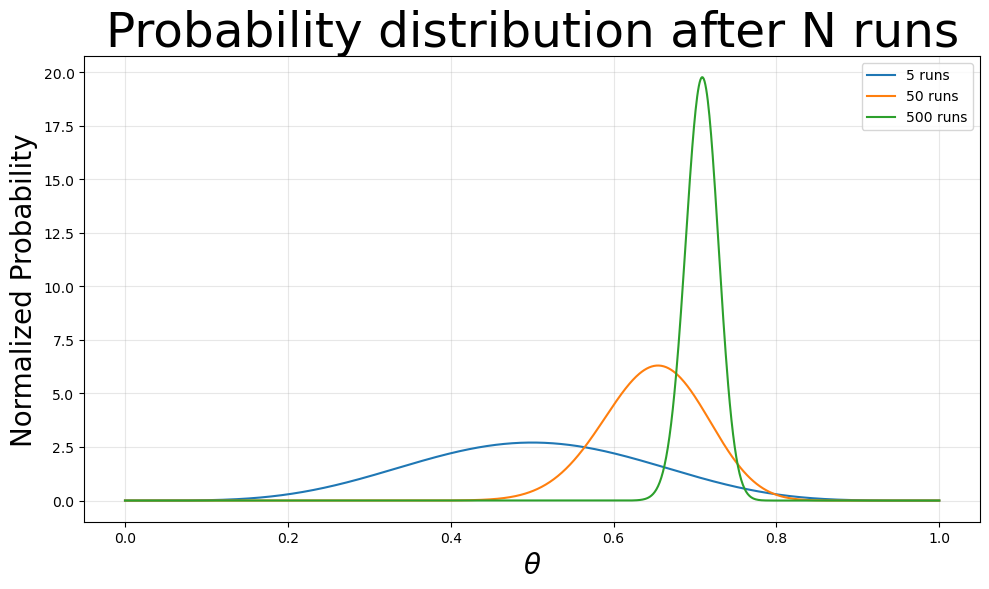

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(theta_vals,ppdf(prior_func,new_run(5),like_func,theta_vals), label = f'5 runs')
plt.plot(theta_vals,ppdf(prior_func,new_run(50),like_func,theta_vals), label = f'50 runs')
plt.plot(theta_vals,ppdf(prior_func,new_run(500),like_func,theta_vals), label = f'500 runs')
plt.xlabel(r'$\theta$', fontsize = 20)
plt.ylabel('Normalized Probability', fontsize = 20)
plt.title(f'Probability distribution after N runs',fontsize = 35)
plt.grid(True, which='both', alpha=0.3)
plt.legend()

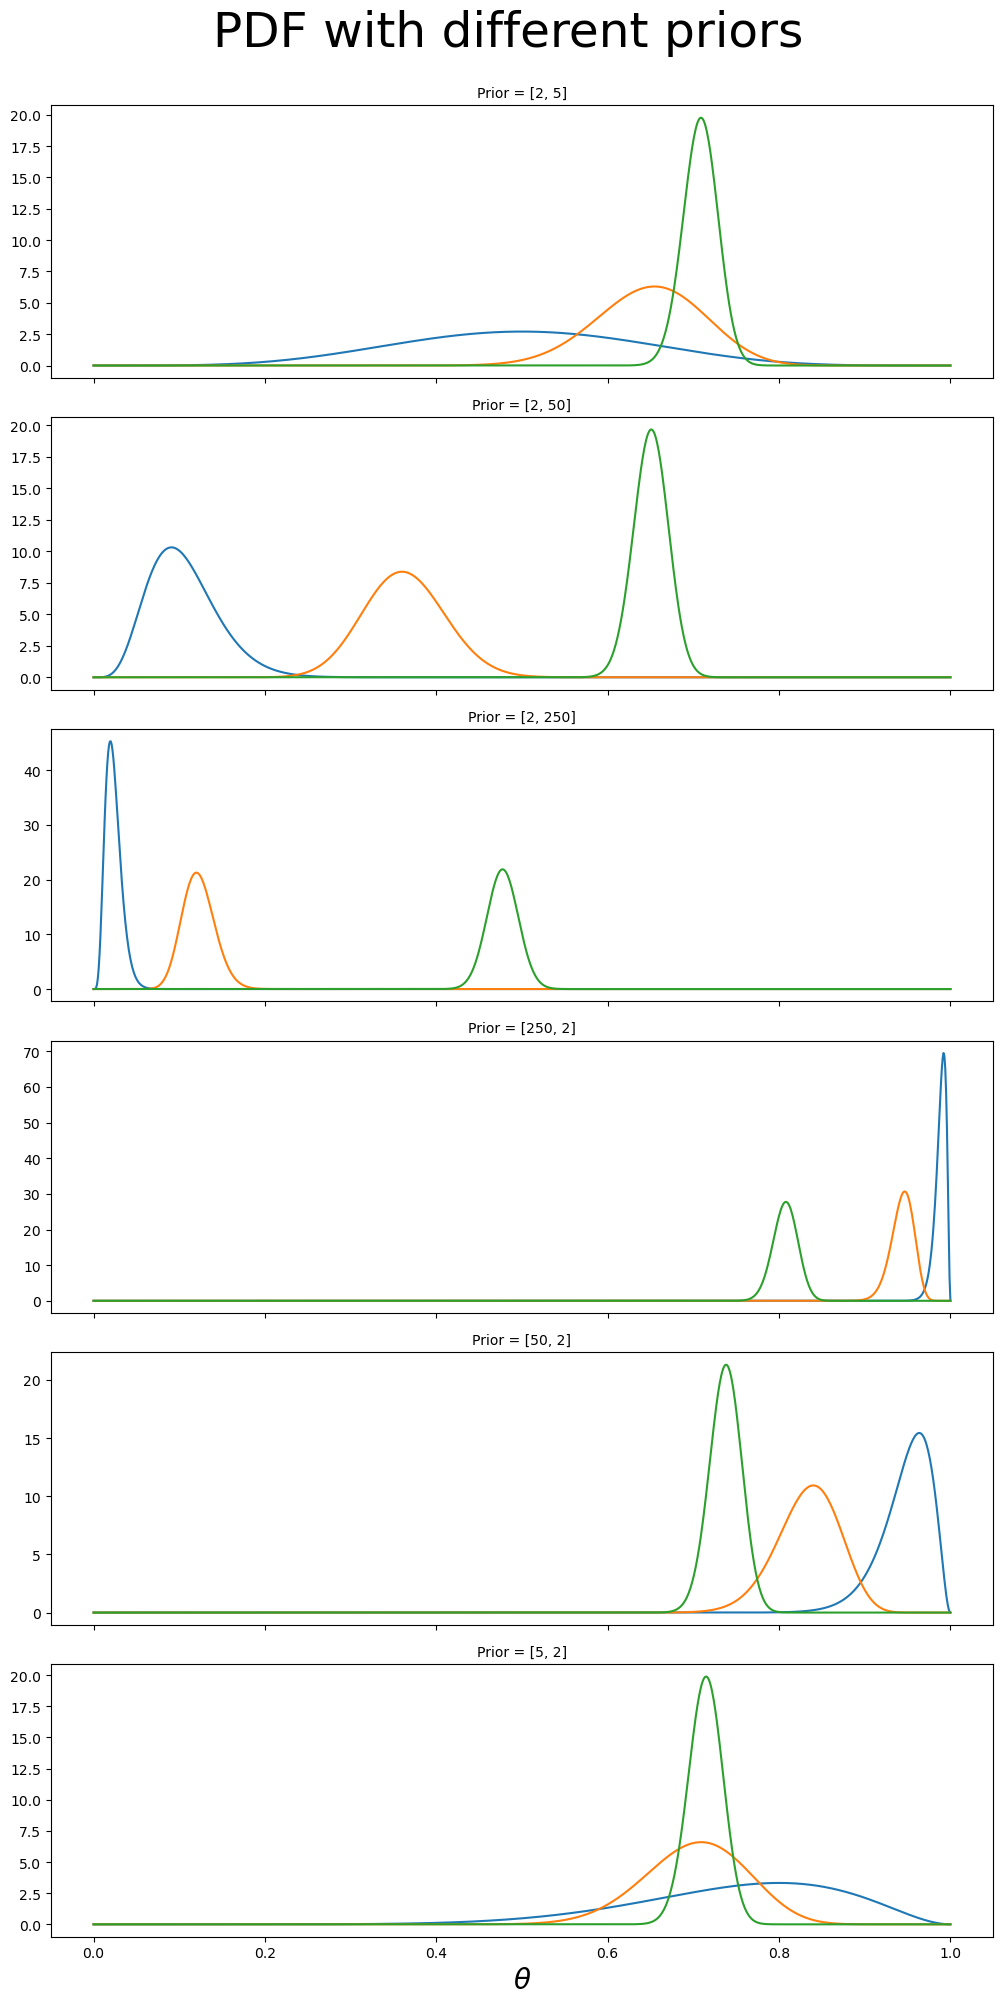

In [36]:
prior_ini_l = [[2,5], [2,50],[2,250],[250,2],[50,2],[5,2]]
fig, axes = plt.subplots(6, 1, figsize=(10, 20), sharex=True)

for ax, prior_ini in zip(axes, prior_ini_l):
    ax.plot(theta_vals,ppdf(prior_func,new_run(5),like_func,theta_vals, prior_ini), label = f'5 runs')
    ax.plot(theta_vals,ppdf(prior_func,new_run(50),like_func,theta_vals,prior_ini), label = f'50 runs')
    ax.plot(theta_vals,ppdf(prior_func,new_run(500),like_func,theta_vals,prior_ini), label = f'500 runs')
    ax.set_title(f'Prior = {prior_ini}',fontsize = 10)
axes[-1].set_xlabel(r'$\theta$', fontsize = 20)

plt.suptitle('PDF with different priors', y= 1, fontsize = 35)
plt.tight_layout()
plt.show()